# Overview
カテゴリ特徴量をエンコーディングしてみる

In [6]:
# 基本
import numpy as np
import pandas as pd

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

# 機械学習
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# 表示設定
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# モデル
import lightgbm as lgb
import catboost as cb

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

train_df.shape, test_df.shape

((1460, 81), (1459, 80))

# データ加工

In [7]:
data = pd.concat([train_df, test_df])
# data.info()

str → category型にキャストする

In [8]:
# エンコードする
qual_map = {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}
data['ExterQual'] = data['ExterQual'].map(qual_map)
data['ExterQual'].head()

0    3
1    2
2    3
3    2
4    3
Name: ExterQual, dtype: int64

In [9]:
# カテゴリ列をcategory型にする
cat_cols = data.select_dtypes(include=["object", "str"]).columns

for col in cat_cols:
  data[col] = data[col].astype("category")

In [10]:
# 家全体の広さを特徴量にする
data['TotalSF'] = (
  data['TotalBsmtSF']
  + data['1stFlrSF']
  + data['2ndFlrSF']
)

trainとtestをわける（もどす）

In [11]:
train_df = data.iloc[:len(train_df)].copy()
test_df = data.iloc[len(train_df):].copy()
test_df = test_df.drop(columns=["SalePrice"])

train_df.shape, test_df.shape

((1460, 82), (1459, 81))

訓練用データの準備をする

In [12]:
X_train = train_df.drop(columns='SalePrice')
y_train = np.log1p(train_df['SalePrice'])

X_train.shape, y_train.shape

((1460, 81), (1460,))

In [13]:
# catboost用にカテゴリ列の欠損を"Missing"で埋めたデータを用意する
cat_cols = X_train.select_dtypes(include=["category"]).columns.tolist()

train_cat_df = train_df.copy()
test_cat_df = test_df.copy()

data = pd.concat([train_cat_df, test_cat_df])

for col in cat_cols:
  data[col] = data[col].cat.add_categories(['Missing']).fillna("Missing")

train_cat_df = data.iloc[:len(train_cat_df)].copy()
test_cat_df = data.iloc[len(train_cat_df):].copy()
test_cat_df = test_cat_df.drop(columns="SalePrice")

train_cat_df.shape, test_cat_df.shape

((1460, 82), (1459, 81))

In [14]:
X_train_cat = train_cat_df.drop(columns="SalePrice")
y_train_cat = np.log1p(train_cat_df['SalePrice'])

X_train_cat.shape, y_train_cat.shape

((1460, 81), (1460,))

# Training
lightGBMにデータ全部入れる

In [15]:
params = {
  "boosting_type": "gbdt",
  "objective": "regression",
  "metric": "rmse",
  "num_iterations": 1000,
  "learning_rate": 0.02,
  "num_leaves": 16,
  "max_depth": -1,
  "min_data_in_leaf": 20,
  "min_sum_hessian_in_leaf": 1e-3,
  "bagging_fraction": 0.9,
  "bagging_freq": 1,
  "feature_fraction": 0.9,
  "lambda_l1": 0.0,
  "lambda_l2": 0.0,
  "random_state": 42,
  "verbosity": -1
}

lgb_model = lgb.LGBMRegressor(**params)
lgb_model.fit(X_train, y_train)

,num_leaves,16
,learning_rate,0.02
,objective,'regression'
,random_state,42
,metric,'rmse'
,num_iterations,1000
,min_data_in_leaf,20
,min_sum_hessian_in_leaf,0.001
,bagging_fraction,0.9
,bagging_freq,1
,feature_fraction,0.9


**Cat Boost**を使ってみる

In [16]:
# CatBoost
cat_boost_model = cb.CatBoostRegressor(
  iterations=1000,
  learning_rate=0.03,
  depth=6,
  loss_function="RMSE",
  verbose=False
)

cat_boost_model.fit(
  X_train_cat,
  y_train_cat,
  cat_features=cat_cols
)

CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.03, loss_function='RMSE', verbose=False)

# CV
回帰なので**KFold**

In [17]:
# lightGBM
kf = KFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

scores = cross_val_score(
  lgb_model,
  X_train,
  y_train,
  cv=kf,
  scoring='neg_root_mean_squared_error'
)

rmse_scores = -scores
print(rmse_scores)

# base lineとの比較
current_lgbm_rmse = rmse_scores.mean()
prev_lgbm_rmse = 0.127711720813

improvement = prev_lgbm_rmse - current_lgbm_rmse
improvement_rate = improvement / prev_lgbm_rmse * 100

print('-'*20)
print(f"Prev LGBM RMSE : {prev_lgbm_rmse:.12f}")
print(f"Current LGBM RMSE  : {current_lgbm_rmse:.12f}")
print(f"Improvement   : {improvement:+.12f}")
print(f"Improvement % : {improvement_rate:+.2f}%")
print('-'*20)

[0.13419044 0.11344523 0.15185153 0.1266209  0.11382972]
--------------------
Prev LGBM RMSE : 0.127711720813
Current LGBM RMSE  : 0.127987562978
Improvement   : -0.000275842165
Improvement % : -0.22%
--------------------


In [18]:
# CatBoost
kf = KFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

scores = cross_val_score(
  cat_boost_model,
  X_train_cat,
  y_train_cat,
  cv=kf,
  scoring='neg_root_mean_squared_error',
  params={
    "cat_features": cat_cols  # cross_val_score内でfitするときにカテゴリ列のリストが必要
  }
)

rmse_scores = -scores
print(rmse_scores)

# base lineとの比較
current_cat_rmse = rmse_scores.mean()
prev_cat_rmse = 0.125420769766

improvement = prev_cat_rmse - current_cat_rmse
improvement_rate = improvement / prev_cat_rmse * 100

print('-'*20)
print(f"Prev CAT RMSE : {prev_cat_rmse:.12f}")
print(f"Current CAT RMSE  : {current_cat_rmse:.12f}")
print(f"Improvement   : {improvement:+.12f}")
print(f"Improvement % : {improvement_rate:+.2f}%")
print('-'*20)

[0.13159871 0.11103837 0.14958299 0.12702749 0.1069833 ]
--------------------
Prev CAT RMSE : 0.125420769766
Current CAT RMSE  : 0.125246170119
Improvement   : +0.000174599647
Improvement % : +0.14%
--------------------


In [19]:
# LGBM_WEIGHT = 0.4
# CAT_BOOST_WEIGHT = 0.6
LGBM_WEIGHT = 0.5
CAT_BOOST_WEIGHT = 0.5
# LGBM_WEIGHT = 0.3
# CAT_BOOST_WEIGHT = 0.7

# EnsembleのRMSEスコアを出したい。

In [20]:
kf = KFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

ensemble_scores = []

for train_idx, val_idx in kf.split(X_train):
  X_tr = X_train.iloc[train_idx]
  X_va   = X_train.iloc[val_idx]

  y_tr = y_train.iloc[train_idx]
  y_va   = y_train.iloc[val_idx]

  X_tr_cat = X_train_cat.iloc[train_idx]
  X_va_cat   = X_train_cat.iloc[val_idx]

  # Learning
  lgb_model.fit(X_tr, y_tr)

  cat_boost_model.fit(
      X_tr_cat,
      y_tr,
      cat_features=cat_cols
  )

  # Prediction
  lgb_pred_log = lgb_model.predict(X_va)
  cat_pred_log = cat_boost_model.predict(X_va_cat)

  # Ensemble
  ensemble_pred_log = (
    LGBM_WEIGHT * lgb_pred_log
    + CAT_BOOST_WEIGHT * cat_pred_log
  )

  # Scoring
  ensemble_rmse = root_mean_squared_error(
    y_va,
    ensemble_pred_log
  )

  ensemble_scores.append(ensemble_rmse)

# export logs
prev_ens_rmse = 0.123029441999
print(ensemble_scores)

current_ens_rmse = np.mean(ensemble_scores)

improvement = prev_ens_rmse - current_ens_rmse
improvement_rate = improvement / prev_ens_rmse * 100

print("===== ENSEMBLE CV RESULT =====")
print(f"Prev RMSE        : {prev_ens_rmse:.12f}")
print(f"Current RMSE     : {current_ens_rmse:.12f}")
print(f"Improvement      : {improvement:+.12f}")
print(f"Improvement rate : {improvement_rate:+.2f}%")

[0.13005622941593672, 0.10836653203633609, 0.14764028442397137, 0.12251918694576236, 0.10635050616875096]
===== ENSEMBLE CV RESULT =====
Prev RMSE        : 0.123029441999
Current RMSE     : 0.122986547798
Improvement      : +0.000042894201
Improvement rate : +0.03%


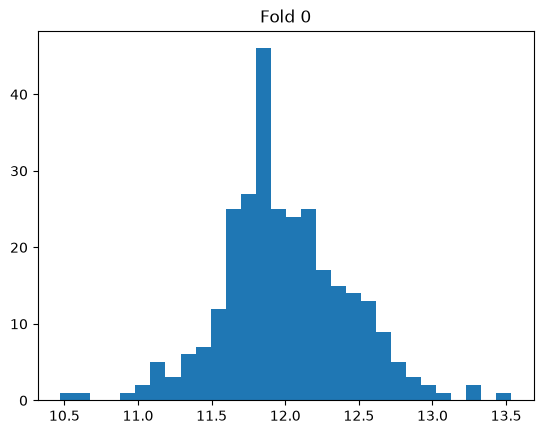

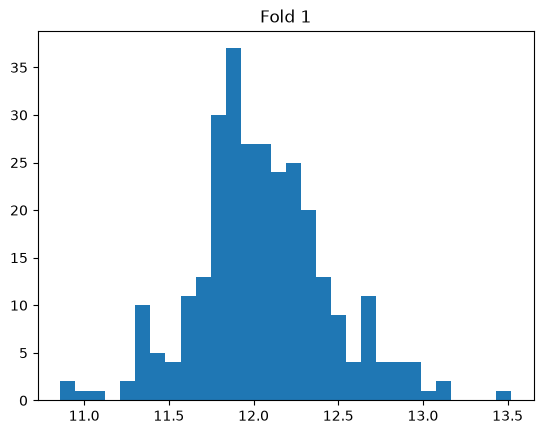

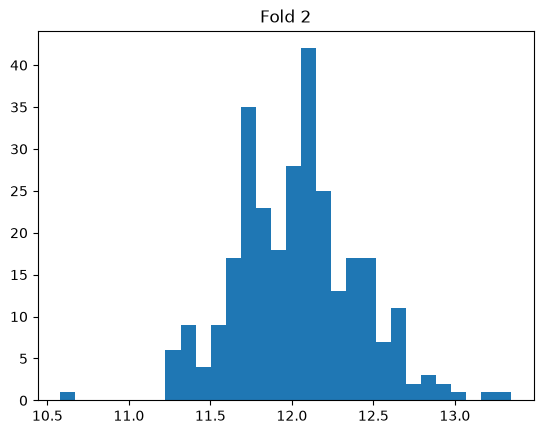

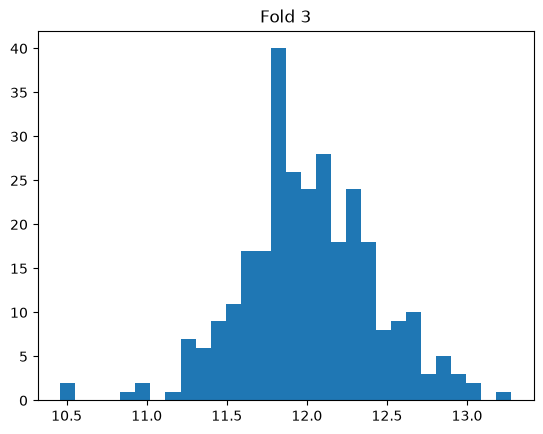

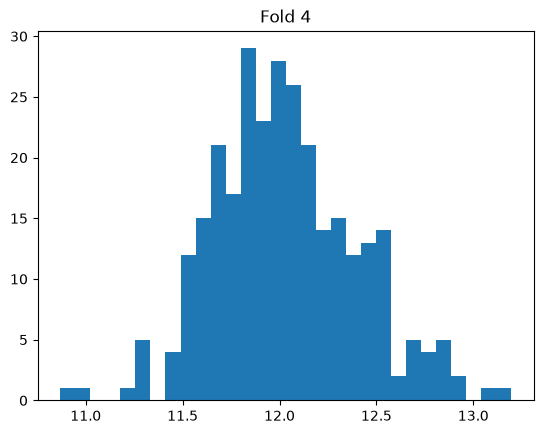

In [ ]:
# import matplotlib.pyplot as plt

# for fold, (_, val_idx) in enumerate(kf.split(X_train)):
#     plt.figure()
#     plt.hist(y_train.iloc[val_idx], bins=30)
#     plt.title(f"Fold {fold}")
#     plt.show()

# Submission
lightGBMとCat Boostのアンサンブル

In [21]:
# lightGBMのprediction
lgb_pred_log = lgb_model.predict(test_df)
lgb_pred = np.expm1(lgb_pred_log) # logをもとに戻すこと！

# cat boostのprediction
cat_pred_log = cat_boost_model.predict(test_cat_df)
cat_pred = np.expm1(cat_pred_log)

# アンサンブル
pred = LGBM_WEIGHT * lgb_pred + CAT_BOOST_WEIGHT * cat_pred

In [22]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": pred
})

submission.to_csv("../submissions/submission.csv", index=False)

In [23]:
submission.shape

(1459, 2)